# Análise Exploratória de Dados — Graduação Indicada

**Disciplina:** Aprendizado de Máquina 2026/1  
**Metodologia:** CRISP-DM — Etapa 2: Entendimento dos Dados  

---

## Contexto

Este projeto visa construir um pipeline de Machine Learning para **recomendar a graduação mais indicada** para um estudante com base em seu perfil pessoal (idade, formação técnica, tempo estimado de conclusão) e suas **10 preferências de interesse** avaliadas em escala de 1 a 5.

O dataset contém **20.000 registros** com **13 features** e **14 classes** de graduação como variável alvo. Trata-se de um problema de **classificação multiclasse supervisionada** com **desbalanceamento** entre as classes.

## Objetivo desta Análise

Compreender a estrutura, qualidade e distribuição dos dados antes de iniciar a modelagem. Especificamente:

1. Verificar a integridade e qualidade dos dados (nulos, duplicados, tipos)
2. Entender a distribuição da variável alvo e o grau de desbalanceamento
3. Analisar o comportamento das features numéricas e categóricas
4. Identificar padrões e relações entre features e a graduação indicada
5. Gerar insights para guiar as decisões de pré-processamento e modelagem

---
## Configuração do Ambiente

Importação das bibliotecas e configuração visual dos gráficos.

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 150

# Pasta para salvar os artefatos (gráficos)
import os
PASTA_ARTEFATOS = "artefatos"
os.makedirs(PASTA_ARTEFATOS, exist_ok=True)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


---
## Etapa 1 — Carregamento e Inspeção Inicial

**Objetivo:** Carregar o dataset, verificar suas dimensões, tipos de dados e visualizar os primeiros registros para ter uma visão geral da estrutura dos dados.

In [2]:
# Carregar o dataset
dados = pd.read_csv("../data/dataset_graduacao_indicada.csv")

# Dimensões do dataset
print(f"Dimensões do dataset: {dados.shape[0]} linhas x {dados.shape[1]} colunas")
print(f"Total de registros: {dados.shape[0]:,}")

Dimensões do dataset: 20000 linhas x 14 colunas
Total de registros: 20,000


In [3]:
# Primeiras 10 linhas do dataset
dados.head(10)

,Idade,Curso_Tecnico,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,Gosta_Negocios,Gosta_Historia,Gosta_Geografia,Graduacao_Indicada
0,45,Sim,7,1,4,2,3,5,3,1,1,5,1,Licenciatura em História
1,31,Sim,7,2,2,1,3,5,3,4,1,5,4,Direito
2,24,Sim,5,1,2,2,2,2,5,5,2,3,5,Direito
3,37,Sim,4,2,1,4,1,3,1,5,5,1,2,Administração
4,35,Sim,6,3,5,5,5,2,1,3,5,1,1,Administração
5,39,Sim,3,4,2,3,4,5,4,4,5,1,5,Administração
6,27,Não,4,2,2,2,3,1,2,2,2,2,3,Design
7,27,Não,5,4,5,2,1,5,4,5,4,5,4,Direito
8,40,Não,6,4,3,4,1,2,5,2,5,1,4,Administração
9,40,Sim,3,5,1,4,4,2,2,4,4,3,1,Direito


In [4]:
# Informações gerais: tipos de dados e uso de memória
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Idade               20000 non-null  int64 
 1   Curso_Tecnico       20000 non-null  object
 2   Anos_Para_Formar    20000 non-null  int64 
 3   Gosta_Matematica    20000 non-null  int64 
 4   Gosta_Programacao   20000 non-null  int64 
 5   Gosta_Biologia      20000 non-null  int64 
 6   Gosta_Fisica        20000 non-null  int64 
 7   Gosta_Quimica       20000 non-null  int64 
 8   Gosta_Arte_Design   20000 non-null  int64 
 9   Gosta_Comunicacao   20000 non-null  int64 
 10  Gosta_Negocios      20000 non-null  int64 
 11  Gosta_Historia      20000 non-null  int64 
 12  Gosta_Geografia     20000 non-null  int64 
 13  Graduacao_Indicada  20000 non-null  object
dtypes: int64(12), object(2)
memory usage: 2.1+ MB


In [5]:
# Estatísticas descritivas das variáveis numéricas
dados.describe().round(2)

,Idade,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,Gosta_Negocios,Gosta_Historia,Gosta_Geografia
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,33.52,5.00,3.00,2.99,3.02,2.99,3.00,2.99,3.00,3.00,3.02,2.99
std,9.75,1.41,1.42,1.42,1.41,1.41,1.42,1.41,1.41,1.41,1.42,1.41
min,17.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,25.00,4.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00
50%,33.00,5.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00
75%,42.00,6.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
max,50.00,7.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [6]:
# Valores únicos por coluna
print("Valores únicos por coluna:")
print("-" * 35)
for coluna in dados.columns:
    print(f"  {coluna:30s} → {dados[coluna].nunique()} valores únicos")

Valores únicos por coluna:
-----------------------------------
  Idade                          → 34 valores únicos
  Curso_Tecnico                  → 2 valores únicos
  Anos_Para_Formar               → 5 valores únicos
  Gosta_Matematica               → 5 valores únicos
  Gosta_Programacao              → 5 valores únicos
  Gosta_Biologia                 → 5 valores únicos
  Gosta_Fisica                   → 5 valores únicos
  Gosta_Quimica                  → 5 valores únicos
  Gosta_Arte_Design              → 5 valores únicos
  Gosta_Comunicacao              → 5 valores únicos
  Gosta_Negocios                 → 5 valores únicos
  Gosta_Historia                 → 5 valores únicos
  Gosta_Geografia                → 5 valores únicos
  Graduacao_Indicada             → 14 valores únicos


### Resultados — Etapa 1

- O dataset possui **20.000 linhas** e **14 colunas** (13 features + 1 alvo).
- **12 variáveis numéricas** (`int64`) e **2 variáveis categóricas** (`object`): `Curso_Tecnico` e `Graduacao_Indicada`.
- **Idade** varia de 17 a 50 anos, com média de ~33.5 anos.
- **Anos_Para_Formar** varia de 3 a 7 anos, com média de ~5 anos.
- As **10 preferências** seguem escala de 1 a 5, todas com média próxima de 3 (distribuição aparentemente uniforme).
- `Curso_Tecnico` tem apenas 2 valores (Sim/Não) e `Graduacao_Indicada` tem 14 classes.

---
## Etapa 2 — Auditoria de Qualidade dos Dados

**Objetivo:** Verificar a existência de valores nulos, duplicados e inconsistências que possam comprometer a modelagem.

In [7]:
# Verificar valores nulos por coluna
nulos_por_coluna = dados.isnull().sum()
total_nulos = nulos_por_coluna.sum()

print("Valores nulos por coluna:")
print("-" * 35)
print(nulos_por_coluna.to_string())
print(f"\nTotal geral de nulos: {total_nulos}")

Valores nulos por coluna:
-----------------------------------
Idade                 0
Curso_Tecnico         0
Anos_Para_Formar      0
Gosta_Matematica      0
Gosta_Programacao     0
Gosta_Biologia        0
Gosta_Fisica          0
Gosta_Quimica         0
Gosta_Arte_Design     0
Gosta_Comunicacao     0
Gosta_Negocios        0
Gosta_Historia        0
Gosta_Geografia       0
Graduacao_Indicada    0

Total geral de nulos: 0


In [8]:
# Verificar linhas duplicadas
total_duplicados = dados.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicados}")

Total de linhas duplicadas: 0


In [9]:
# Verificar consistência dos valores nas preferências (devem estar entre 1 e 5)
colunas_preferencias = [
    "Gosta_Matematica", "Gosta_Programacao", "Gosta_Biologia",
    "Gosta_Fisica", "Gosta_Quimica", "Gosta_Arte_Design",
    "Gosta_Comunicacao", "Gosta_Negocios", "Gosta_Historia", "Gosta_Geografia"
]

print("Verificação de faixa de valores nas preferências (esperado: 1 a 5):")
print("-" * 55)
for coluna in colunas_preferencias:
    minimo = dados[coluna].min()
    maximo = dados[coluna].max()
    status = "OK" if minimo >= 1 and maximo <= 5 else "PROBLEMA"
    print(f"  {coluna:25s} → min={minimo}, max={maximo}  [{status}]")

Verificação de faixa de valores nas preferências (esperado: 1 a 5):
-------------------------------------------------------
  Gosta_Matematica          → min=1, max=5  [OK]
  Gosta_Programacao         → min=1, max=5  [OK]
  Gosta_Biologia            → min=1, max=5  [OK]
  Gosta_Fisica              → min=1, max=5  [OK]
  Gosta_Quimica             → min=1, max=5  [OK]
  Gosta_Arte_Design         → min=1, max=5  [OK]
  Gosta_Comunicacao         → min=1, max=5  [OK]
  Gosta_Negocios            → min=1, max=5  [OK]
  Gosta_Historia            → min=1, max=5  [OK]
  Gosta_Geografia           → min=1, max=5  [OK]


In [10]:
# Verificar valores válidos nas variáveis categóricas
print("Valores únicos em 'Curso_Tecnico':")
print(dados["Curso_Tecnico"].value_counts())

print(f"\nValores únicos em 'Graduacao_Indicada': {dados['Graduacao_Indicada'].nunique()} classes")
print(dados["Graduacao_Indicada"].value_counts())

Valores únicos em 'Curso_Tecnico':
Curso_Tecnico
Sim    10094
Não     9906
Name: count, dtype: int64

Valores únicos em 'Graduacao_Indicada': 14 classes
Graduacao_Indicada
Administração                 4620
Direito                       3618
Design                        2809
Medicina                      2386
Odontologia                   1563
Educação Física                930
Psicologia                     859
Ciência da Computação          755
Licenciatura em Matemática     714
Engenharia                     676
Licenciatura em História       444
Licenciatura em Geografia      287
Comunicação Social             209
Licenciatura em Biologia       130
Name: count, dtype: int64


### Resultados — Etapa 2

- **Zero valores nulos** em todas as colunas — não será necessário imputação.
- **Zero linhas duplicadas** — cada registro é único.
- Todas as **preferências estão dentro da faixa esperada** (1 a 5) — sem outliers ou erros de digitação.
- `Curso_Tecnico` contém apenas "Sim" e "Não" — sem valores inesperados.
- **Conclusão**: O dataset está limpo e pronto para análise. Nenhuma etapa de limpeza é necessária.

---
## Etapa 3 — Distribuição da Variável Alvo

**Objetivo:** Analisar a distribuição das 14 classes de graduação para quantificar o desbalanceamento e entender seu impacto na escolha de métricas e estratégias de modelagem.

In [11]:
# Contagem e proporção de cada classe
contagem_classes = dados["Graduacao_Indicada"].value_counts()
proporcao_classes = dados["Graduacao_Indicada"].value_counts(normalize=True) * 100

# Tabela resumo
tabela_alvo = pd.DataFrame({
    "Quantidade": contagem_classes,
    "Proporção (%)": proporcao_classes.round(2)
})
tabela_alvo["Acumulado (%)"] = tabela_alvo["Proporção (%)"].cumsum().round(2)

print("Distribuição da Variável Alvo — Graduação Indicada")
print("=" * 55)
print(tabela_alvo.to_string())
print(f"\nRazão de desbalanceamento (maior/menor): {contagem_classes.max() / contagem_classes.min():.1f}x")

Distribuição da Variável Alvo — Graduação Indicada
                            Quantidade  Proporção (%)  Acumulado (%)
Graduacao_Indicada                                                  
Administração                     4620          23.10          23.10
Direito                           3618          18.09          41.19
Design                            2809          14.04          55.23
Medicina                          2386          11.93          67.16
Odontologia                       1563           7.82          74.98
Educação Física                    930           4.65          79.63
Psicologia                         859           4.30          83.93
Ciência da Computação              755           3.78          87.71
Licenciatura em Matemática         714           3.57          91.28
Engenharia                         676           3.38          94.66
Licenciatura em História           444           2.22          96.88
Licenciatura em Geografia          287           1.4

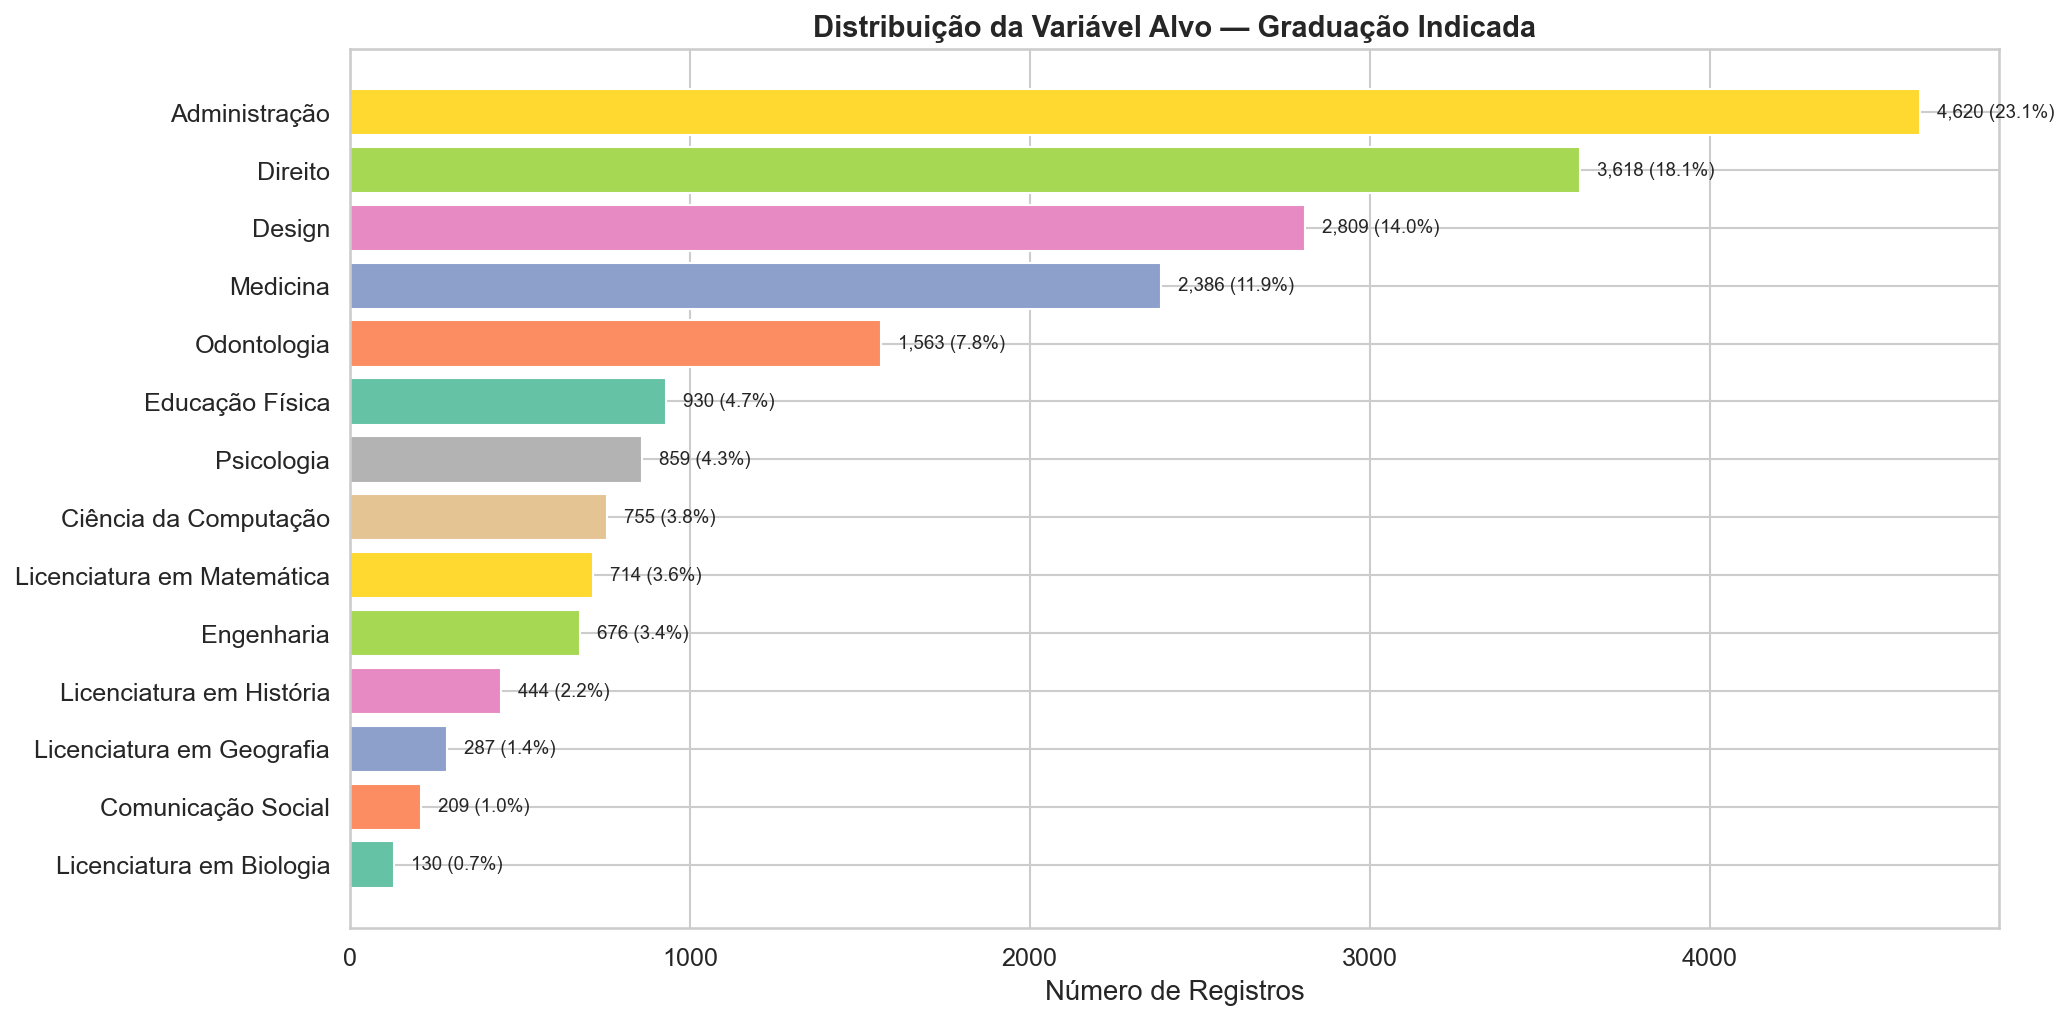

Gráfico salvo em: artefatos/01_distribuicao_variavel_alvo.png


In [12]:
# Gráfico de barras — Distribuição da variável alvo
fig, ax = plt.subplots(figsize=(14, 7))

cores = sns.color_palette("Set2", n_colors=len(contagem_classes))
barras = ax.barh(contagem_classes.index[::-1], contagem_classes.values[::-1], color=cores)

# Adicionar valores nas barras
for barra, valor in zip(barras, contagem_classes.values[::-1]):
    porcentagem = valor / len(dados) * 100
    ax.text(valor + 50, barra.get_y() + barra.get_height() / 2,
            f"{valor:,} ({porcentagem:.1f}%)", va="center", fontsize=9)

ax.set_xlabel("Número de Registros")
ax.set_title("Distribuição da Variável Alvo — Graduação Indicada", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/01_distribuicao_variavel_alvo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/01_distribuicao_variavel_alvo.png")

### Resultados — Etapa 3

- O dataset é **significativamente desbalanceado**, com razão de **35.5x** entre a classe majoritária e a minoritária.
- **Administração** (4.620 registros, 23.1%) e **Direito** (3.618, 18.1%) concentram juntas **41.2%** dos dados.
- As **4 classes majoritárias** (Administração, Direito, Design, Medicina) representam **67.2%** do total.
- As **classes minoritárias** mais críticas são: Licenciatura em Biologia (130, 0.65%), Comunicação Social (209, 1.05%) e Licenciatura em Geografia (287, 1.44%).
- **Impacto na modelagem**: A acurácia não é uma métrica adequada isoladamente — um modelo que preveja sempre "Administração" teria ~23% de acurácia. Devemos usar **F1-Score Macro** como métrica principal e considerar o split **estratificado**.

---
## Etapa 4 — Análise das Variáveis Numéricas (Idade e Anos para Formar)

**Objetivo:** Entender a distribuição das variáveis pessoais `Idade` e `Anos_Para_Formar`, identificar padrões e verificar se há diferenças entre as graduações.

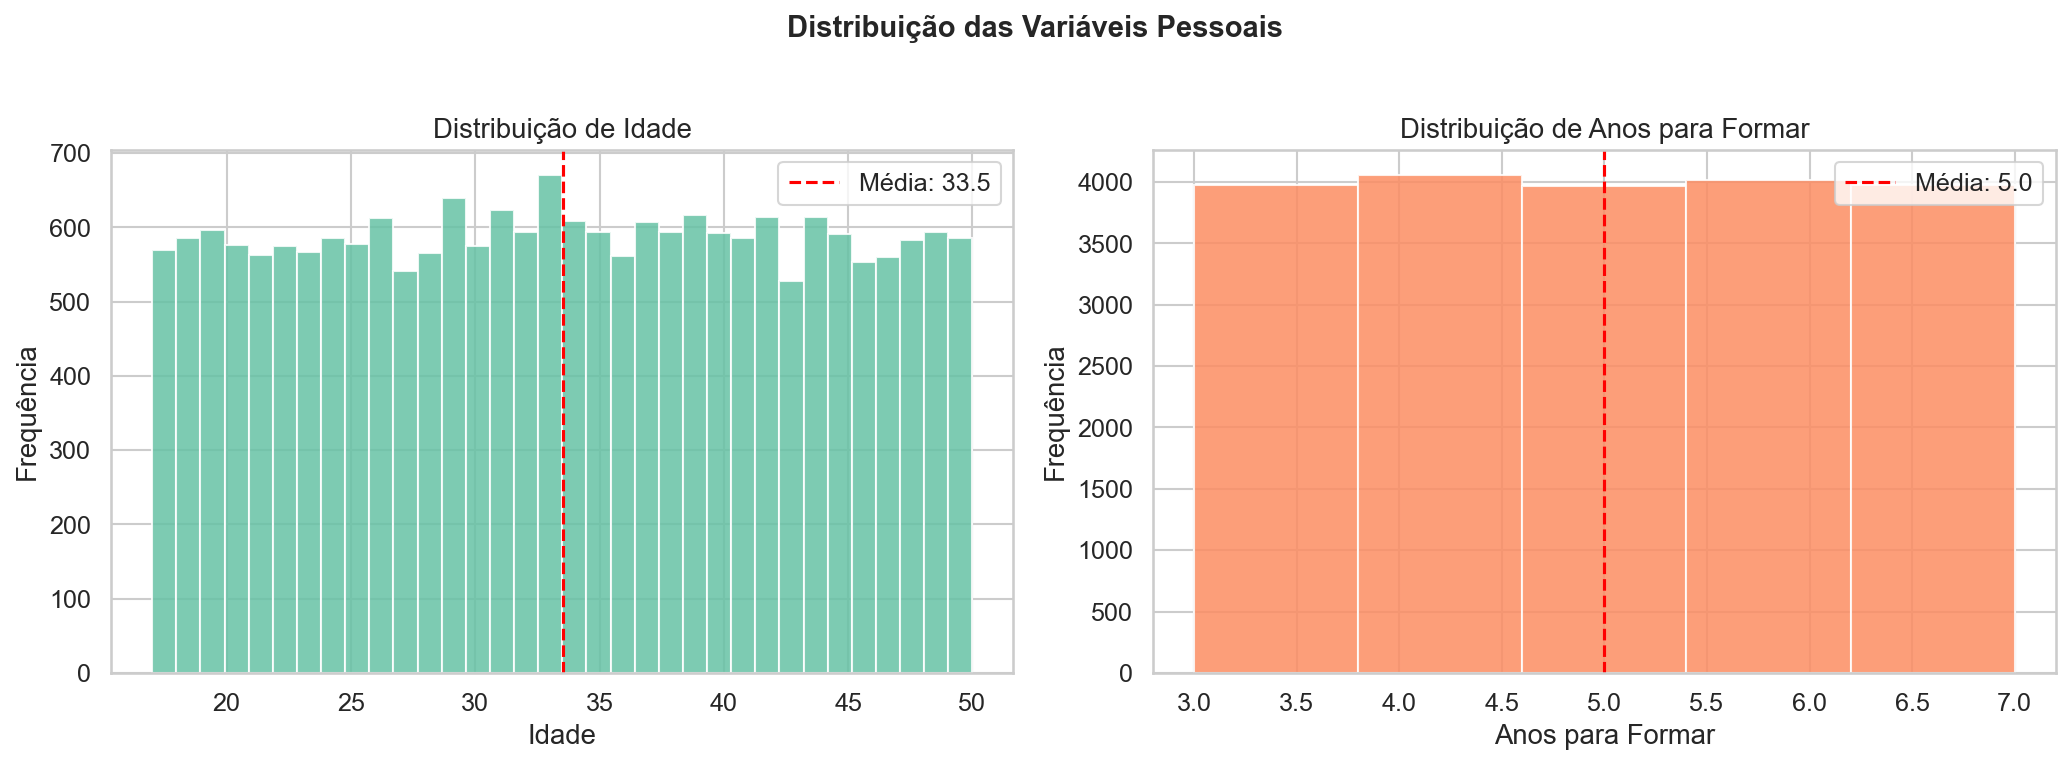

Gráfico salvo em: artefatos/02_distribuicao_idade_anos.png


In [13]:
# Histogramas de Idade e Anos_Para_Formar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Idade
axes[0].hist(dados["Idade"], bins=34, color="#66c2a5", edgecolor="white", alpha=0.85)
axes[0].axvline(dados["Idade"].mean(), color="red", linestyle="--", label=f"Média: {dados['Idade'].mean():.1f}")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição de Idade")
axes[0].legend()

# Anos para Formar
axes[1].hist(dados["Anos_Para_Formar"], bins=5, color="#fc8d62", edgecolor="white", alpha=0.85)
axes[1].axvline(dados["Anos_Para_Formar"].mean(), color="red", linestyle="--", label=f"Média: {dados['Anos_Para_Formar'].mean():.1f}")
axes[1].set_xlabel("Anos para Formar")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição de Anos para Formar")
axes[1].legend()

plt.suptitle("Distribuição das Variáveis Pessoais", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/02_distribuicao_idade_anos.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/02_distribuicao_idade_anos.png")

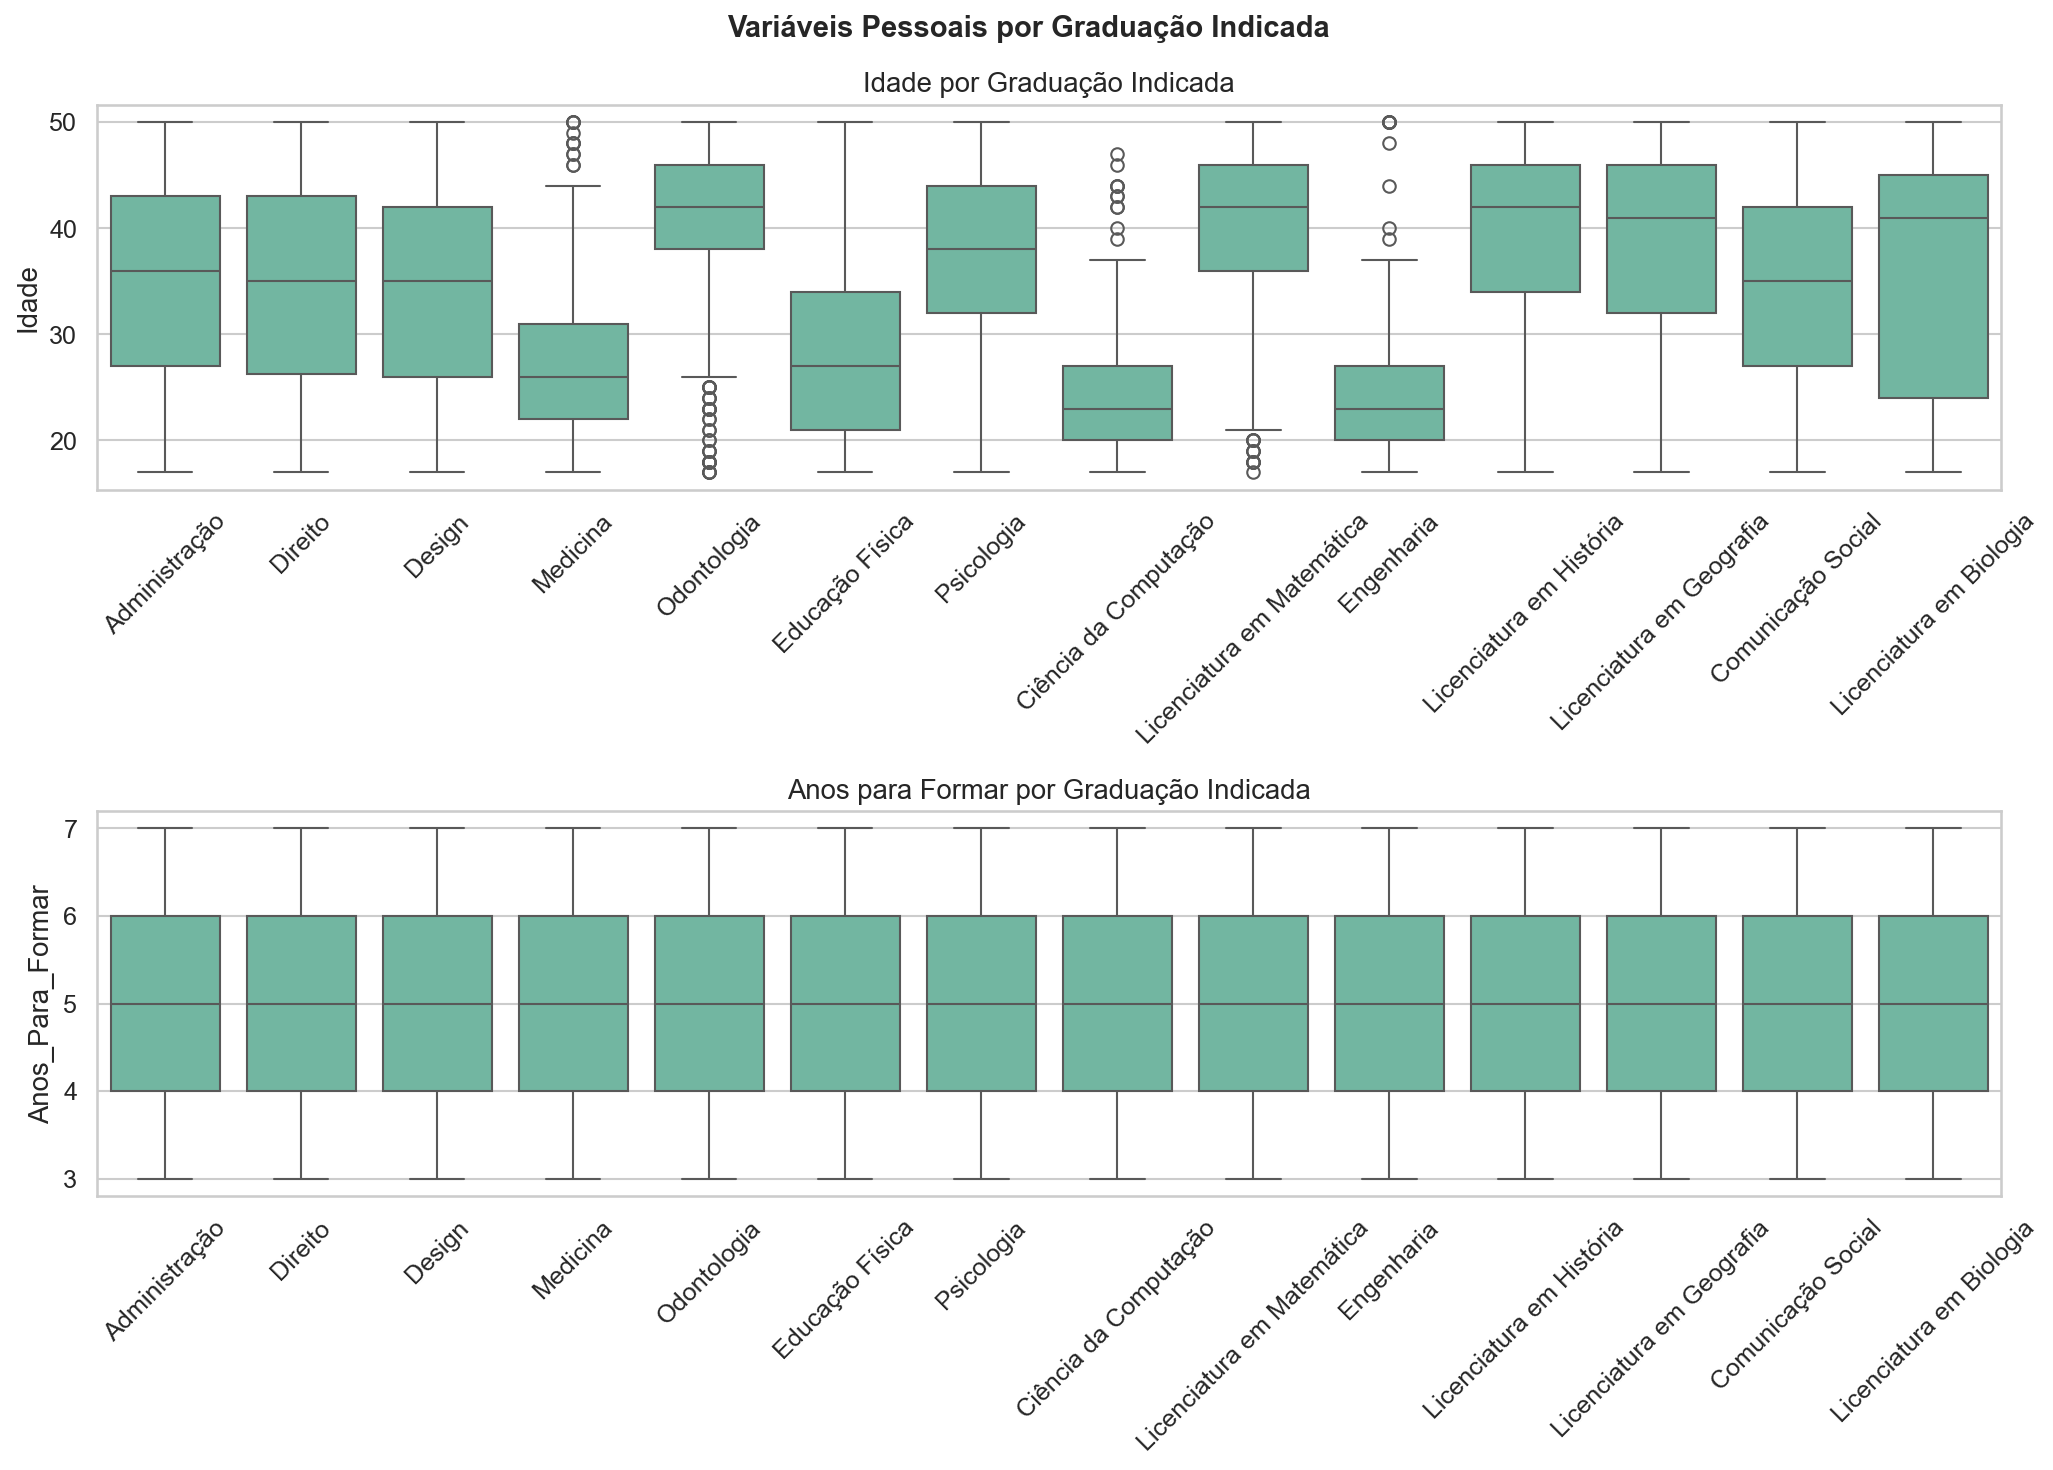

Gráfico salvo em: artefatos/03_boxplot_idade_anos_por_graduacao.png


In [14]:
# Boxplots de Idade e Anos_Para_Formar por Graduação Indicada
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Ordenar classes por quantidade (para manter consistência visual)
ordem_classes = contagem_classes.index.tolist()

# Boxplot — Idade por Graduação
sns.boxplot(data=dados, x="Graduacao_Indicada", y="Idade", order=ordem_classes, ax=axes[0])
axes[0].set_title("Idade por Graduação Indicada")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Boxplot — Anos para Formar por Graduação
sns.boxplot(data=dados, x="Graduacao_Indicada", y="Anos_Para_Formar", order=ordem_classes, ax=axes[1])
axes[1].set_title("Anos para Formar por Graduação Indicada")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Variáveis Pessoais por Graduação Indicada", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/03_boxplot_idade_anos_por_graduacao.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/03_boxplot_idade_anos_por_graduacao.png")

### Resultados — Etapa 4

- A **Idade** apresenta distribuição aproximadamente uniforme entre 17 e 50 anos, com média de 33.5 — não há concentração em faixas etárias específicas.
- **Anos_Para_Formar** varia de 3 a 7 anos com distribuição uniforme (média ~5).
- Os boxplots mostram que **Idade e Anos_Para_Formar têm distribuição semelhante entre todas as graduações** — essas variáveis, isoladamente, não parecem ser altamente discriminativas.
- **Insight**: A diferenciação entre as graduações provavelmente vem mais das **preferências de interesse** do que das variáveis pessoais.

---
## Etapa 5 — Análise das Preferências de Interesse (Escala 1-5)

**Objetivo:** Analisar a distribuição individual das 10 preferências de interesse e verificar se alguma apresenta padrão diferente das demais.

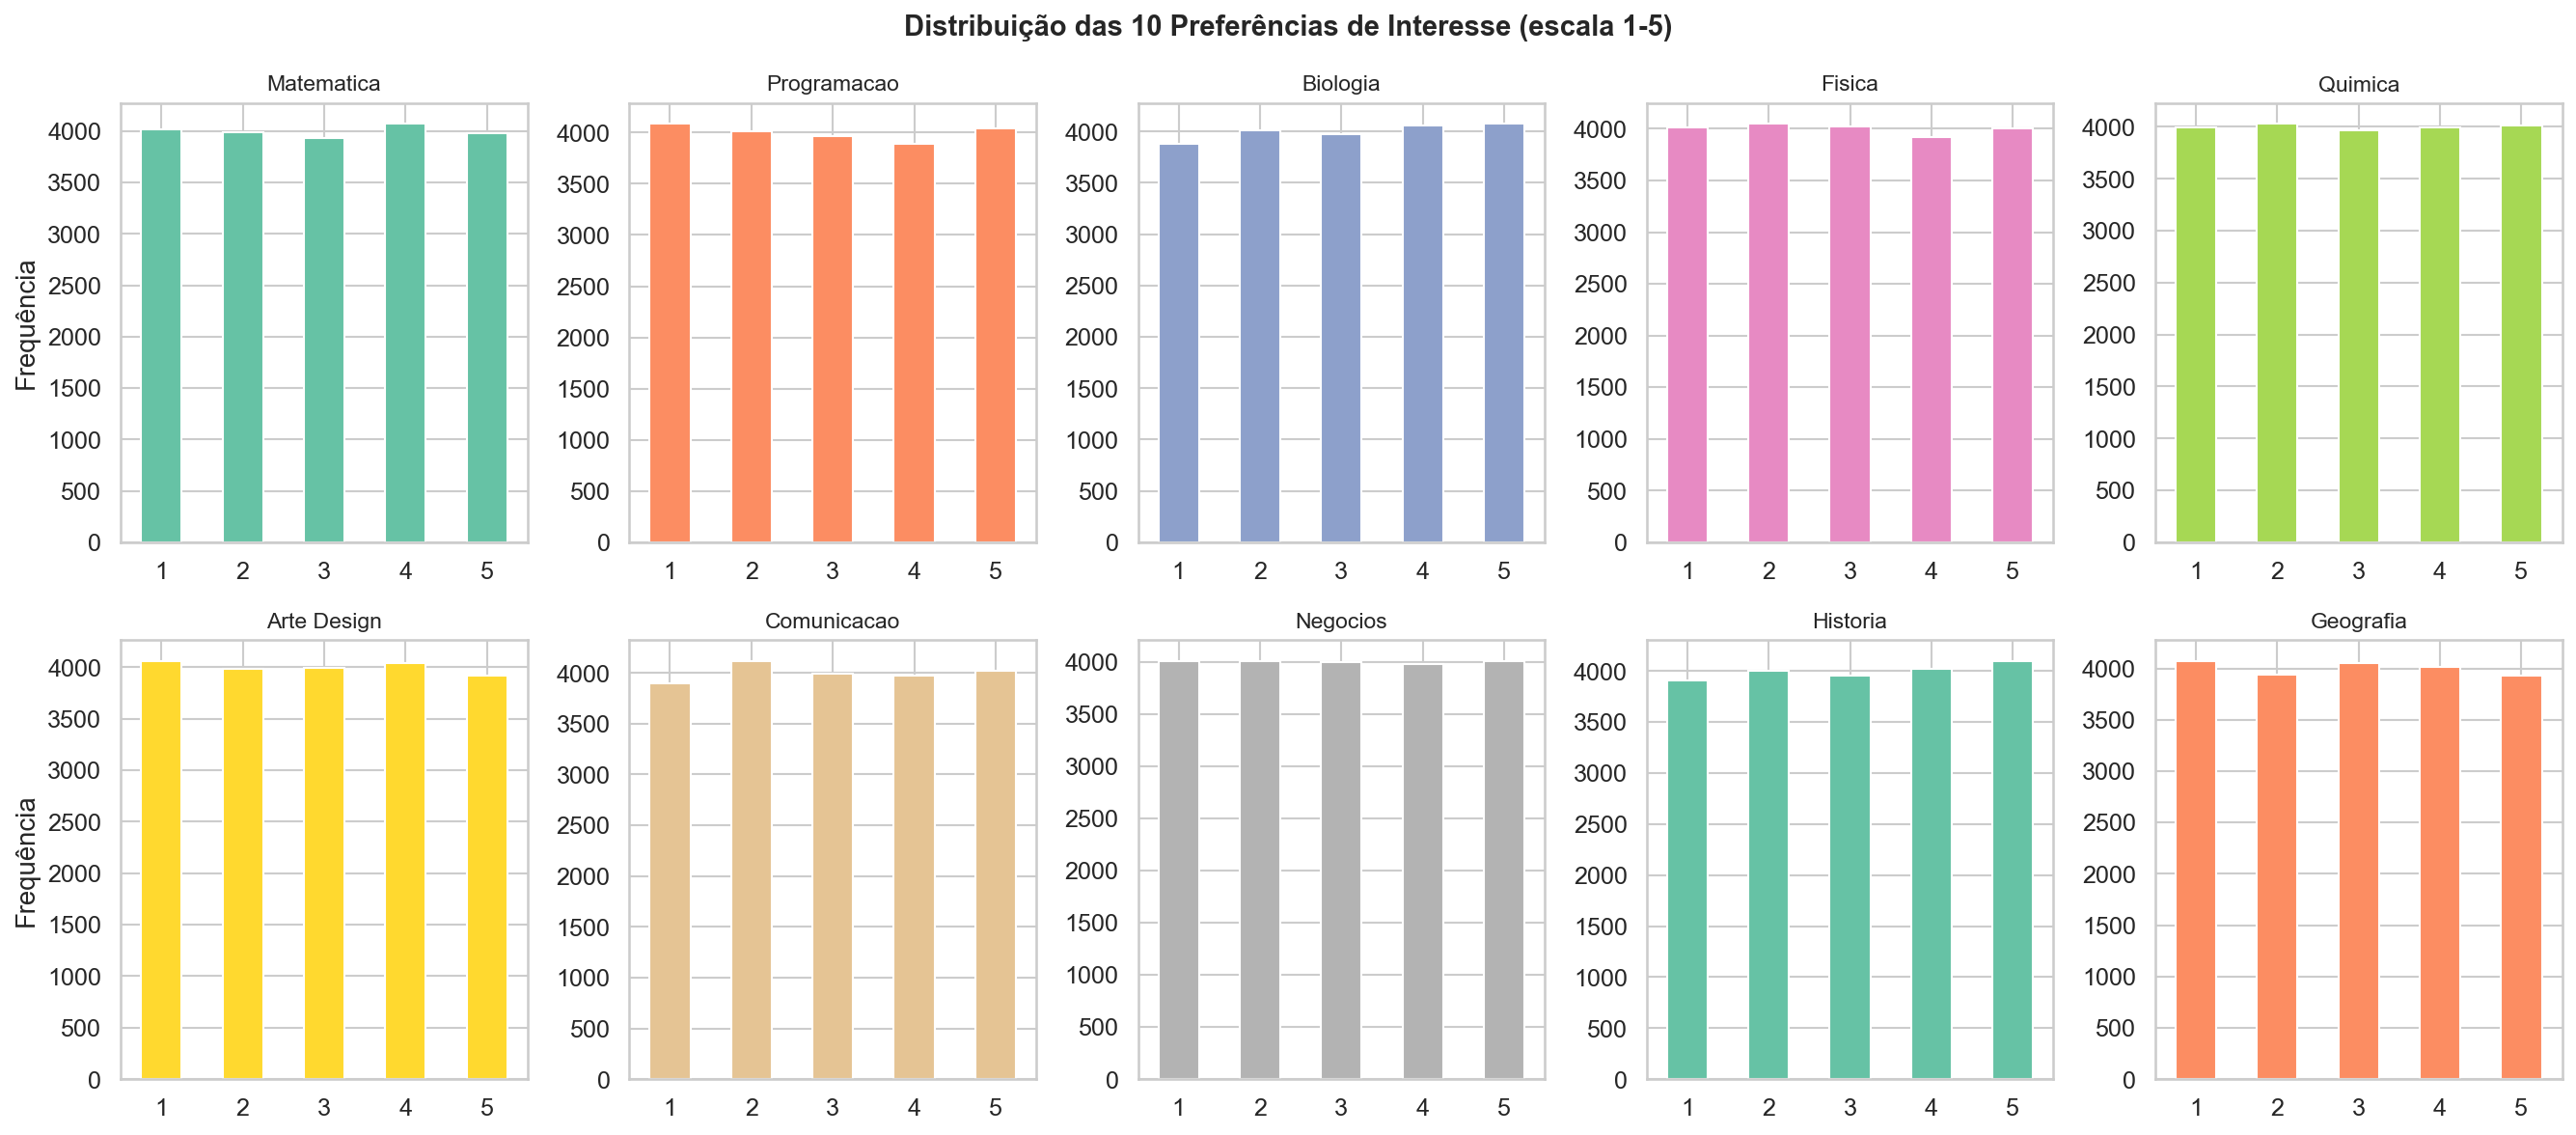

Gráfico salvo em: artefatos/04_distribuicao_preferencias.png


In [15]:
# Histogramas das 10 preferências
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, coluna in enumerate(colunas_preferencias):
    # Nome legível (remover prefixo "Gosta_")
    nome_legivel = coluna.replace("Gosta_", "").replace("_", " ")
    
    dados[coluna].value_counts().sort_index().plot(
        kind="bar", ax=axes[i], color=cores[i % len(cores)], edgecolor="white"
    )
    axes[i].set_title(nome_legivel, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequência" if i % 5 == 0 else "")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Distribuição das 10 Preferências de Interesse (escala 1-5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/04_distribuicao_preferencias.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/04_distribuicao_preferencias.png")

In [16]:
# Estatísticas descritivas das preferências
tabela_preferencias = dados[colunas_preferencias].describe().round(2)
tabela_preferencias.columns = [c.replace("Gosta_", "") for c in tabela_preferencias.columns]
tabela_preferencias

,Matematica,Programacao,Biologia,Fisica,Quimica,Arte_Design,Comunicacao,Negocios,Historia,Geografia
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,3.00,2.99,3.02,2.99,3.00,2.99,3.00,3.00,3.02,2.99
std,1.42,1.42,1.41,1.41,1.42,1.41,1.41,1.41,1.42,1.41
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00
50%,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00
75%,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


### Resultados — Etapa 5

- Todas as 10 preferências apresentam **distribuição aproximadamente uniforme** nos valores de 1 a 5.
- As **médias estão próximas de 3.0** para todas as preferências, com desvio padrão de ~1.41.
- Não há preferência com comportamento anômalo ou enviesado — o dataset parece ter sido gerado com distribuição balanceada nas features.
- **Insight**: A diferenciação entre as classes não vem de uma única preferência dominante, mas sim da **combinação** das preferências — reforçando a necessidade de modelos que capturem interações entre features.

---
## Etapa 6 — Correlação entre as Preferências

**Objetivo:** Verificar se há correlações lineares entre as preferências que possam indicar redundância ou multicolinearidade.

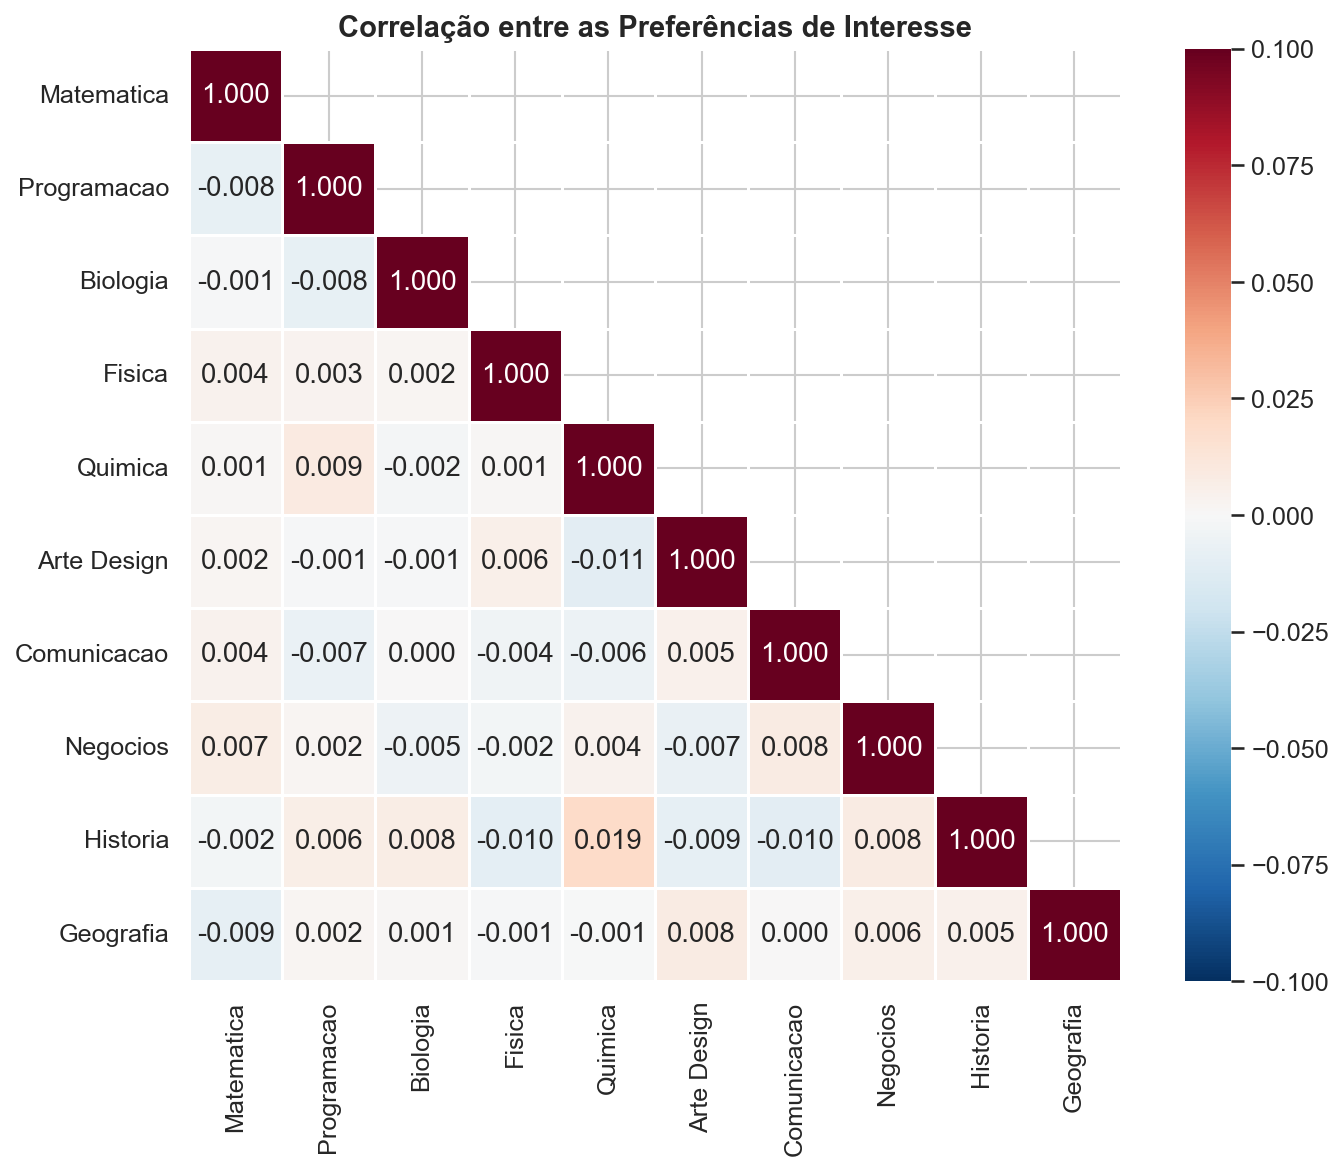

Gráfico salvo em: artefatos/05_heatmap_correlacao_preferencias.png


In [17]:
# Heatmap de correlação entre as 10 preferências
correlacao = dados[colunas_preferencias].corr()

# Renomear para legibilidade
nomes_curtos = [c.replace("Gosta_", "").replace("_", " ") for c in colunas_preferencias]
correlacao.index = nomes_curtos
correlacao.columns = nomes_curtos

fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(correlacao, dtype=bool), k=1)

sns.heatmap(
    correlacao,
    mask=mascara,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.1,
    vmax=0.1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlação entre as Preferências de Interesse", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/05_heatmap_correlacao_preferencias.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/05_heatmap_correlacao_preferencias.png")

### Resultados — Etapa 6

- As correlações entre todas as preferências são **extremamente baixas** (todas < 0.02 em valor absoluto).
- **Não há multicolinearidade** entre as features — cada preferência carrega informação independente.
- Isso é positivo para a modelagem: todas as 10 features contribuem com informação distinta e nenhuma é redundante.
- **Insight**: Não será necessário remover features por correlação alta. Todas as 10 preferências devem ser mantidas no modelo.

---
## Etapa 7 — Análise da Feature Categórica: Curso Técnico

**Objetivo:** Analisar a distribuição de `Curso_Tecnico` e verificar se há relação entre possuir curso técnico e a graduação indicada.

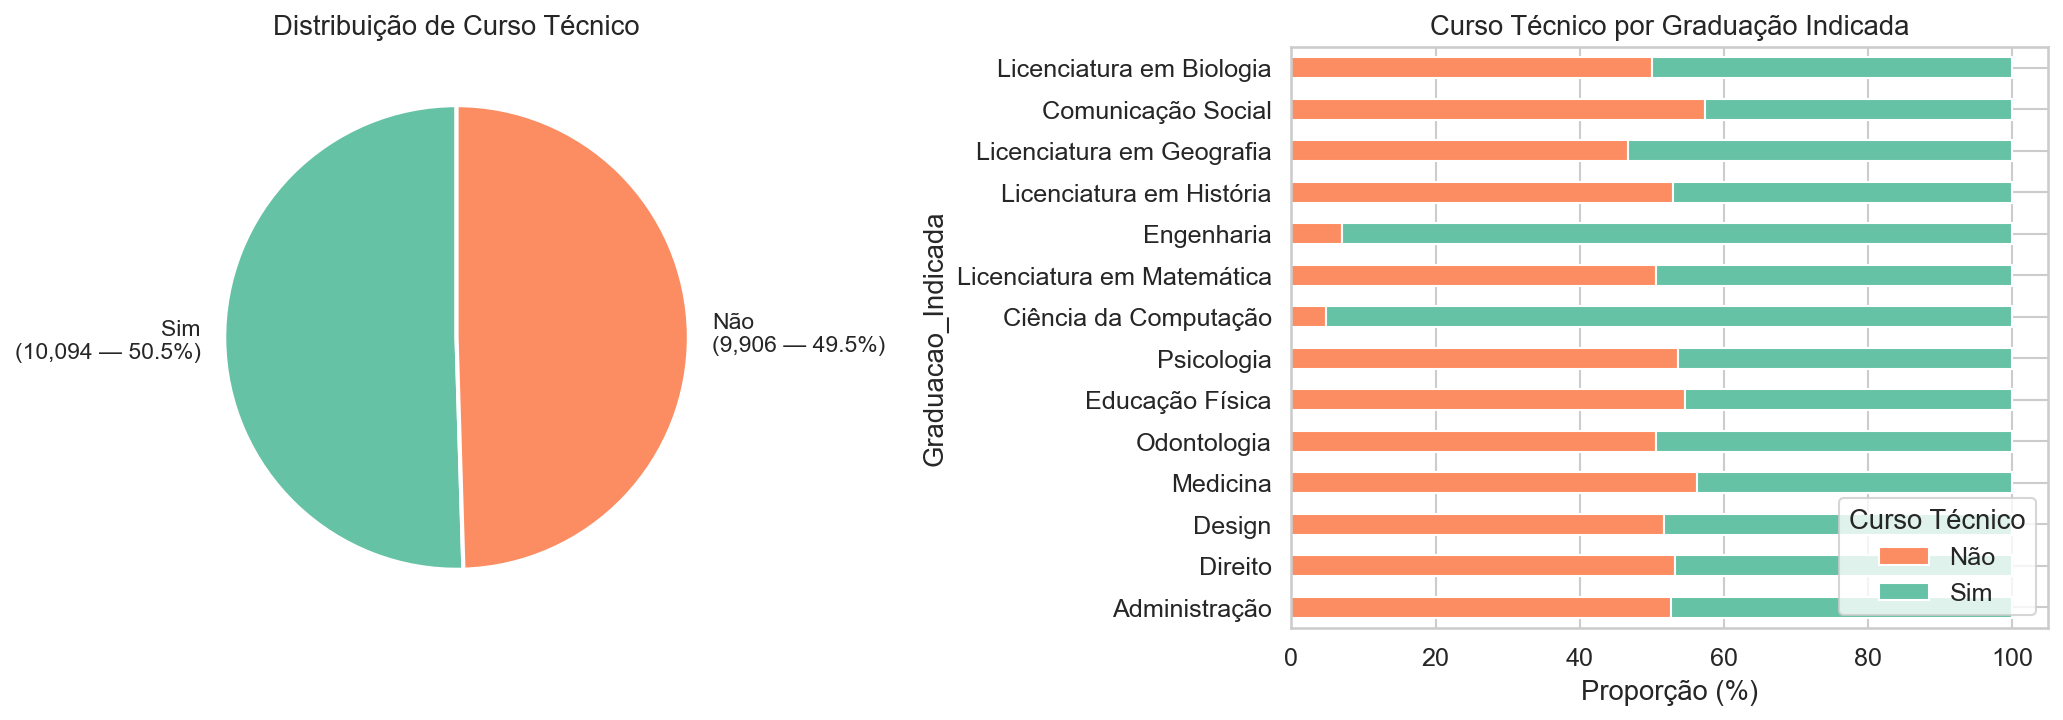

Gráfico salvo em: artefatos/06_curso_tecnico_por_graduacao.png


In [18]:
# Distribuição de Curso Técnico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pizza
contagem_ct = dados["Curso_Tecnico"].value_counts()
axes[0].pie(
    contagem_ct.values,
    labels=[f"{label}\n({valor:,} — {valor/len(dados)*100:.1f}%)" for label, valor in contagem_ct.items()],
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
axes[0].set_title("Distribuição de Curso Técnico")

# Curso Técnico por Graduação
ct_por_grad = pd.crosstab(dados["Graduacao_Indicada"], dados["Curso_Tecnico"], normalize="index") * 100
ct_por_grad = ct_por_grad.loc[ordem_classes]

ct_por_grad.plot(kind="barh", stacked=True, ax=axes[1], color=["#fc8d62", "#66c2a5"], edgecolor="white")
axes[1].set_xlabel("Proporção (%)")
axes[1].set_title("Curso Técnico por Graduação Indicada")
axes[1].legend(title="Curso Técnico", loc="lower right")

plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/06_curso_tecnico_por_graduacao.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/06_curso_tecnico_por_graduacao.png")

### Resultados — Etapa 7

- A distribuição geral de `Curso_Tecnico` é equilibrada: **Sim (50.5%)** vs **Não (49.5%)**.
- No entanto, há **diferenças marcantes** entre as graduações:
  - **Ciência da Computação**: 95.2% possuem curso técnico — fortíssima associação.
  - **Engenharia**: 93.0% possuem curso técnico — padrão semelhante.
  - **Demais graduações**: proporção próxima de 50/50, sem diferenciação clara.
- **Insight**: `Curso_Tecnico` é uma feature **altamente discriminativa para Ciência da Computação e Engenharia**, mas pouco relevante para as demais classes. Esse é um sinal importante para o modelo.

---
## Etapa 8 — Perfil Médio de Preferências por Graduação

**Objetivo:** Identificar quais preferências são mais relevantes para cada graduação, criando um "perfil médio" por classe que revele padrões discriminativos.

In [19]:
# Tabela de média das preferências por graduação
perfil_medio = dados.groupby("Graduacao_Indicada")[colunas_preferencias].mean().round(2)
perfil_medio.columns = [c.replace("Gosta_", "") for c in perfil_medio.columns]
perfil_medio = perfil_medio.loc[ordem_classes]

print("Perfil Médio de Preferências por Graduação")
print("=" * 80)
perfil_medio

Perfil Médio de Preferências por Graduação


,Matematica,Programacao,Biologia,Fisica,Quimica,Arte_Design,Comunicacao,Negocios,Historia,Geografia
Graduacao_Indicada,,,,,,,,,,
Administração,2.92,2.96,2.63,2.97,2.69,2.96,2.55,4.47,2.70,3.01
Direito,2.91,2.94,2.62,2.94,2.71,2.99,4.47,2.97,3.98,2.98
Design,2.91,2.92,2.61,2.96,2.69,4.43,2.51,2.00,2.66,2.98
Medicina,2.82,2.93,4.40,2.95,3.98,2.93,3.01,2.97,3.04,3.02
Odontologia,3.03,2.95,4.37,3.04,4.44,2.91,2.98,2.92,3.04,2.96
Educação Física,2.84,2.79,3.50,2.88,2.43,2.00,2.00,2.00,2.90,2.96
Psicologia,2.90,2.86,3.50,3.02,2.45,1.97,3.51,1.99,2.36,2.91
Ciência da Computação,3.73,4.38,2.94,2.48,3.07,2.90,3.02,2.94,2.97,2.89
Licenciatura em Matemática,4.31,3.01,2.10,3.04,2.83,1.93,2.18,2.02,2.86,3.02


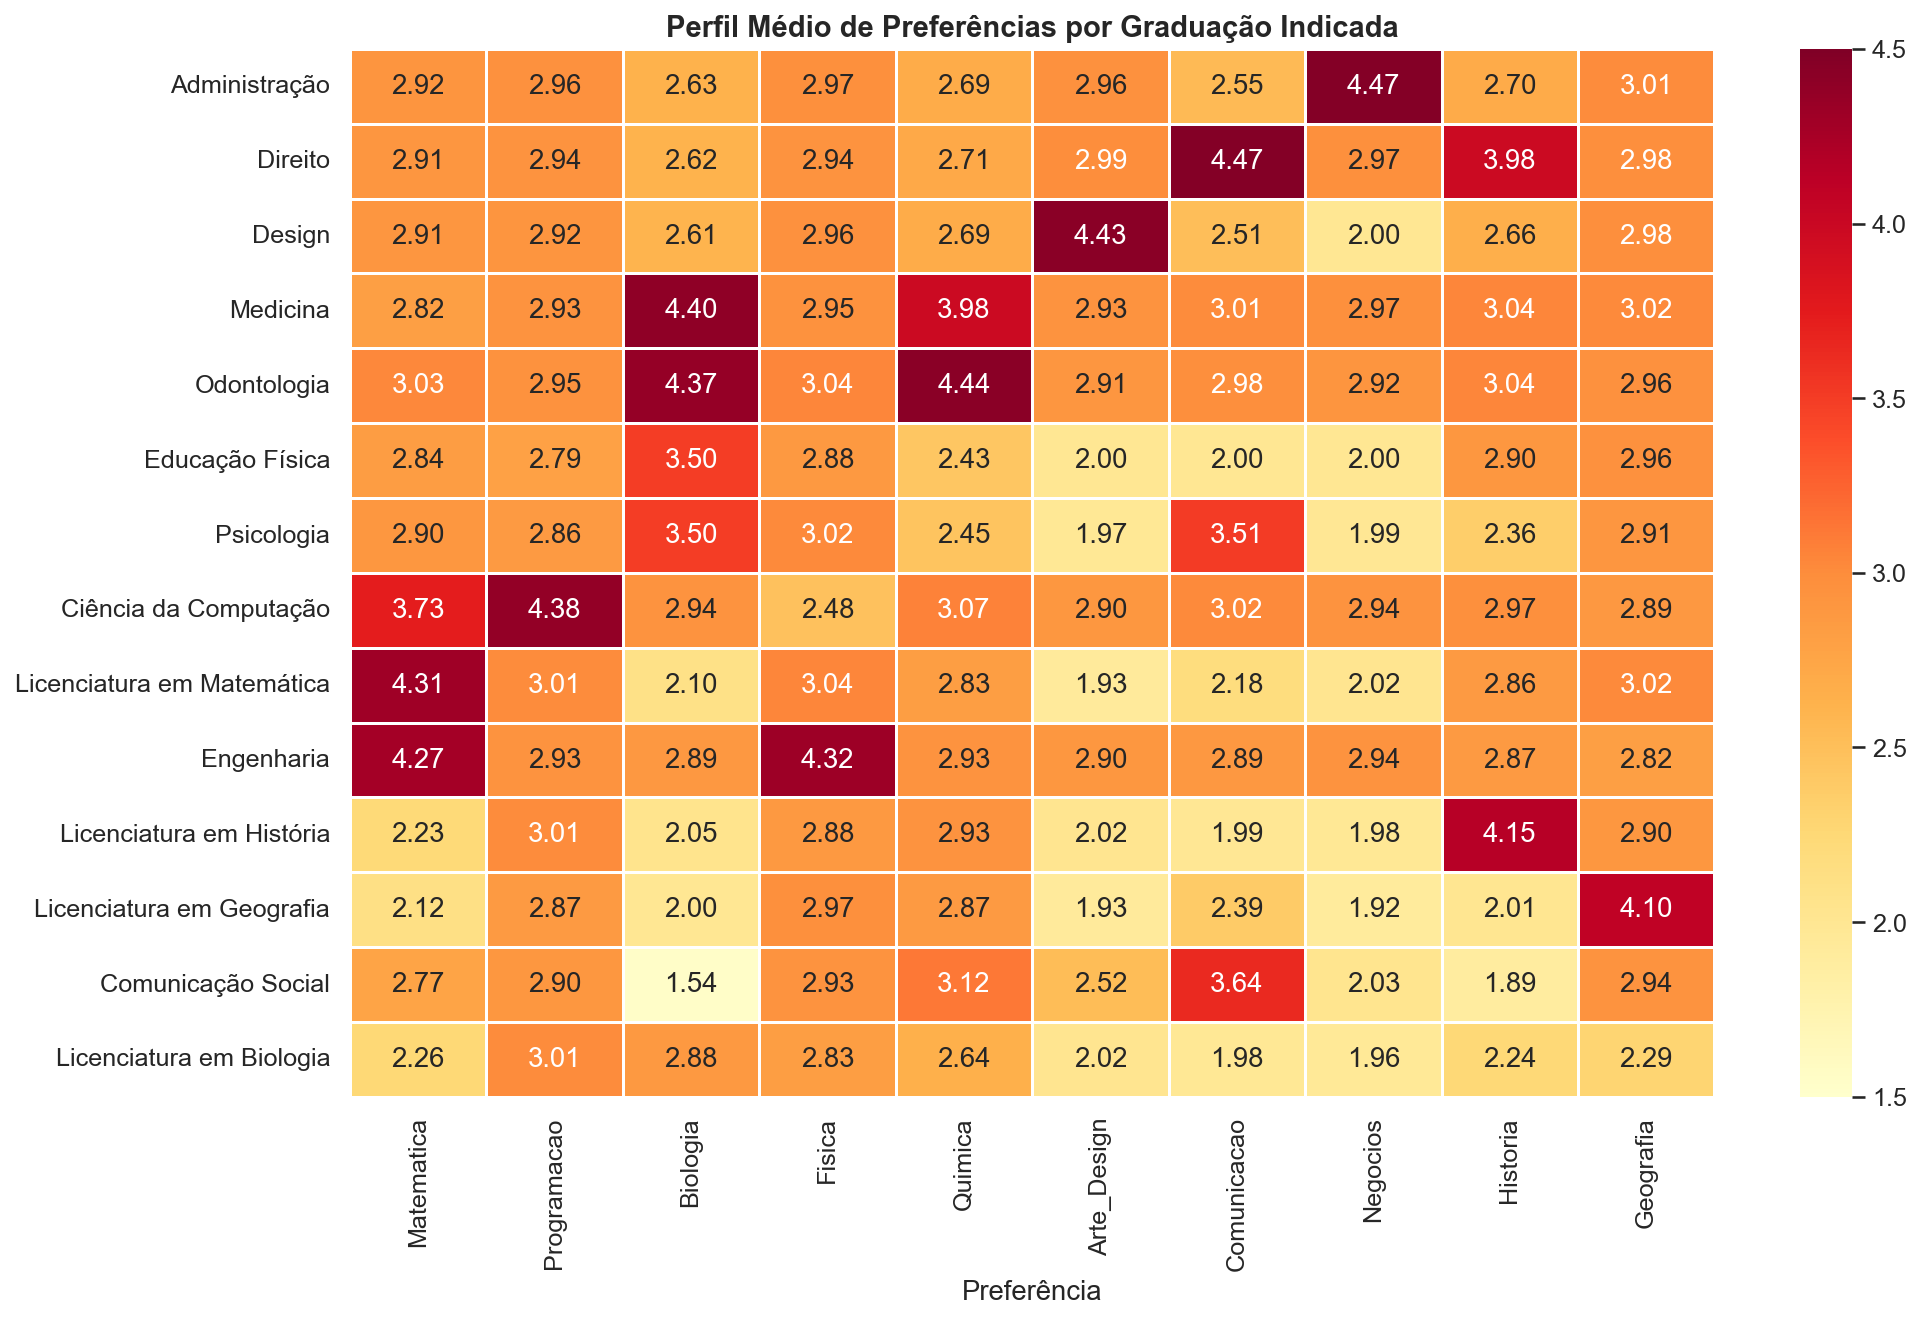

Gráfico salvo em: artefatos/07_heatmap_perfil_medio_por_graduacao.png


In [20]:
# Heatmap do perfil médio de preferências por graduação
fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    perfil_medio,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=1.5,
    vmax=4.5,
)
ax.set_title("Perfil Médio de Preferências por Graduação Indicada", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("Preferência")

plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/07_heatmap_perfil_medio_por_graduacao.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/07_heatmap_perfil_medio_por_graduacao.png")

In [21]:
# Identificar a preferência mais alta e mais baixa para cada graduação
print("Preferência MAIS FORTE e MAIS FRACA por graduação:")
print("=" * 70)
for grad in ordem_classes:
    valores = perfil_medio.loc[grad]
    mais_forte = valores.idxmax()
    mais_fraca = valores.idxmin()
    print(f"  {grad:30s} → Forte: {mais_forte} ({valores[mais_forte]:.2f}) | Fraca: {mais_fraca} ({valores[mais_fraca]:.2f})")

Preferência MAIS FORTE e MAIS FRACA por graduação:
  Administração                  → Forte: Negocios (4.47) | Fraca: Comunicacao (2.55)
  Direito                        → Forte: Comunicacao (4.47) | Fraca: Biologia (2.62)
  Design                         → Forte: Arte_Design (4.43) | Fraca: Negocios (2.00)
  Medicina                       → Forte: Biologia (4.40) | Fraca: Matematica (2.82)
  Odontologia                    → Forte: Quimica (4.44) | Fraca: Arte_Design (2.91)
  Educação Física                → Forte: Biologia (3.50) | Fraca: Arte_Design (2.00)
  Psicologia                     → Forte: Comunicacao (3.51) | Fraca: Arte_Design (1.97)
  Ciência da Computação          → Forte: Programacao (4.38) | Fraca: Fisica (2.48)
  Licenciatura em Matemática     → Forte: Matematica (4.31) | Fraca: Arte_Design (1.93)
  Engenharia                     → Forte: Fisica (4.32) | Fraca: Geografia (2.82)
  Licenciatura em História       → Forte: Historia (4.15) | Fraca: Negocios (1.98)
  Licenci

### Resultados — Etapa 8

O heatmap revela **padrões claros e discriminativos** por graduação. As preferências dominantes para cada curso:

| Graduação | Preferência Dominante | Média |
|---|---|---|
| Administração | Negócios | 4.47 |
| Ciência da Computação | Programação | 4.38 |
| Design | Arte e Design | 4.43 |
| Direito | Comunicação + História | 4.47 / 3.98 |
| Engenharia | Física + Matemática | 4.32 / 4.27 |
| Licenciatura em Matemática | Matemática | 4.31 |
| Medicina | Biologia + Química | 4.40 / 3.98 |
| Odontologia | Química + Biologia | 4.44 / 4.37 |
| Psicologia | Comunicação + Biologia | 3.51 / 3.50 |

- **Insight principal**: As preferências de interesse são as features mais discriminativas do dataset. Cada graduação tem um "perfil de preferências" distinto, com uma ou duas preferências claramente acima da média (>4.0).
- Graduações como **Medicina e Odontologia** compartilham perfis semelhantes (Biologia + Química alta), o que pode gerar confusão no modelo.
- Classes minoritárias como **Licenciatura em Biologia** e **Comunicação Social** têm perfis menos marcantes (preferências mais baixas, ~3.5), dificultando a separação.

---
## Etapa 9 — Análise de Distribuição das Preferências por Graduação (Boxplots)

**Objetivo:** Visualizar a variabilidade das preferências mais relevantes dentro de cada classe, complementando a análise das médias com a dispersão dos dados.

C:\Users\reyna\AppData\Local\Temp\ipykernel_9184\1428573812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\reyna\AppData\Local\Temp\ipykernel_9184\1428573812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\reyna\AppData\Local\Temp\ipykernel_9184\1428573812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\reyna\AppData\Local\Temp\ipykernel_9184\1428573812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

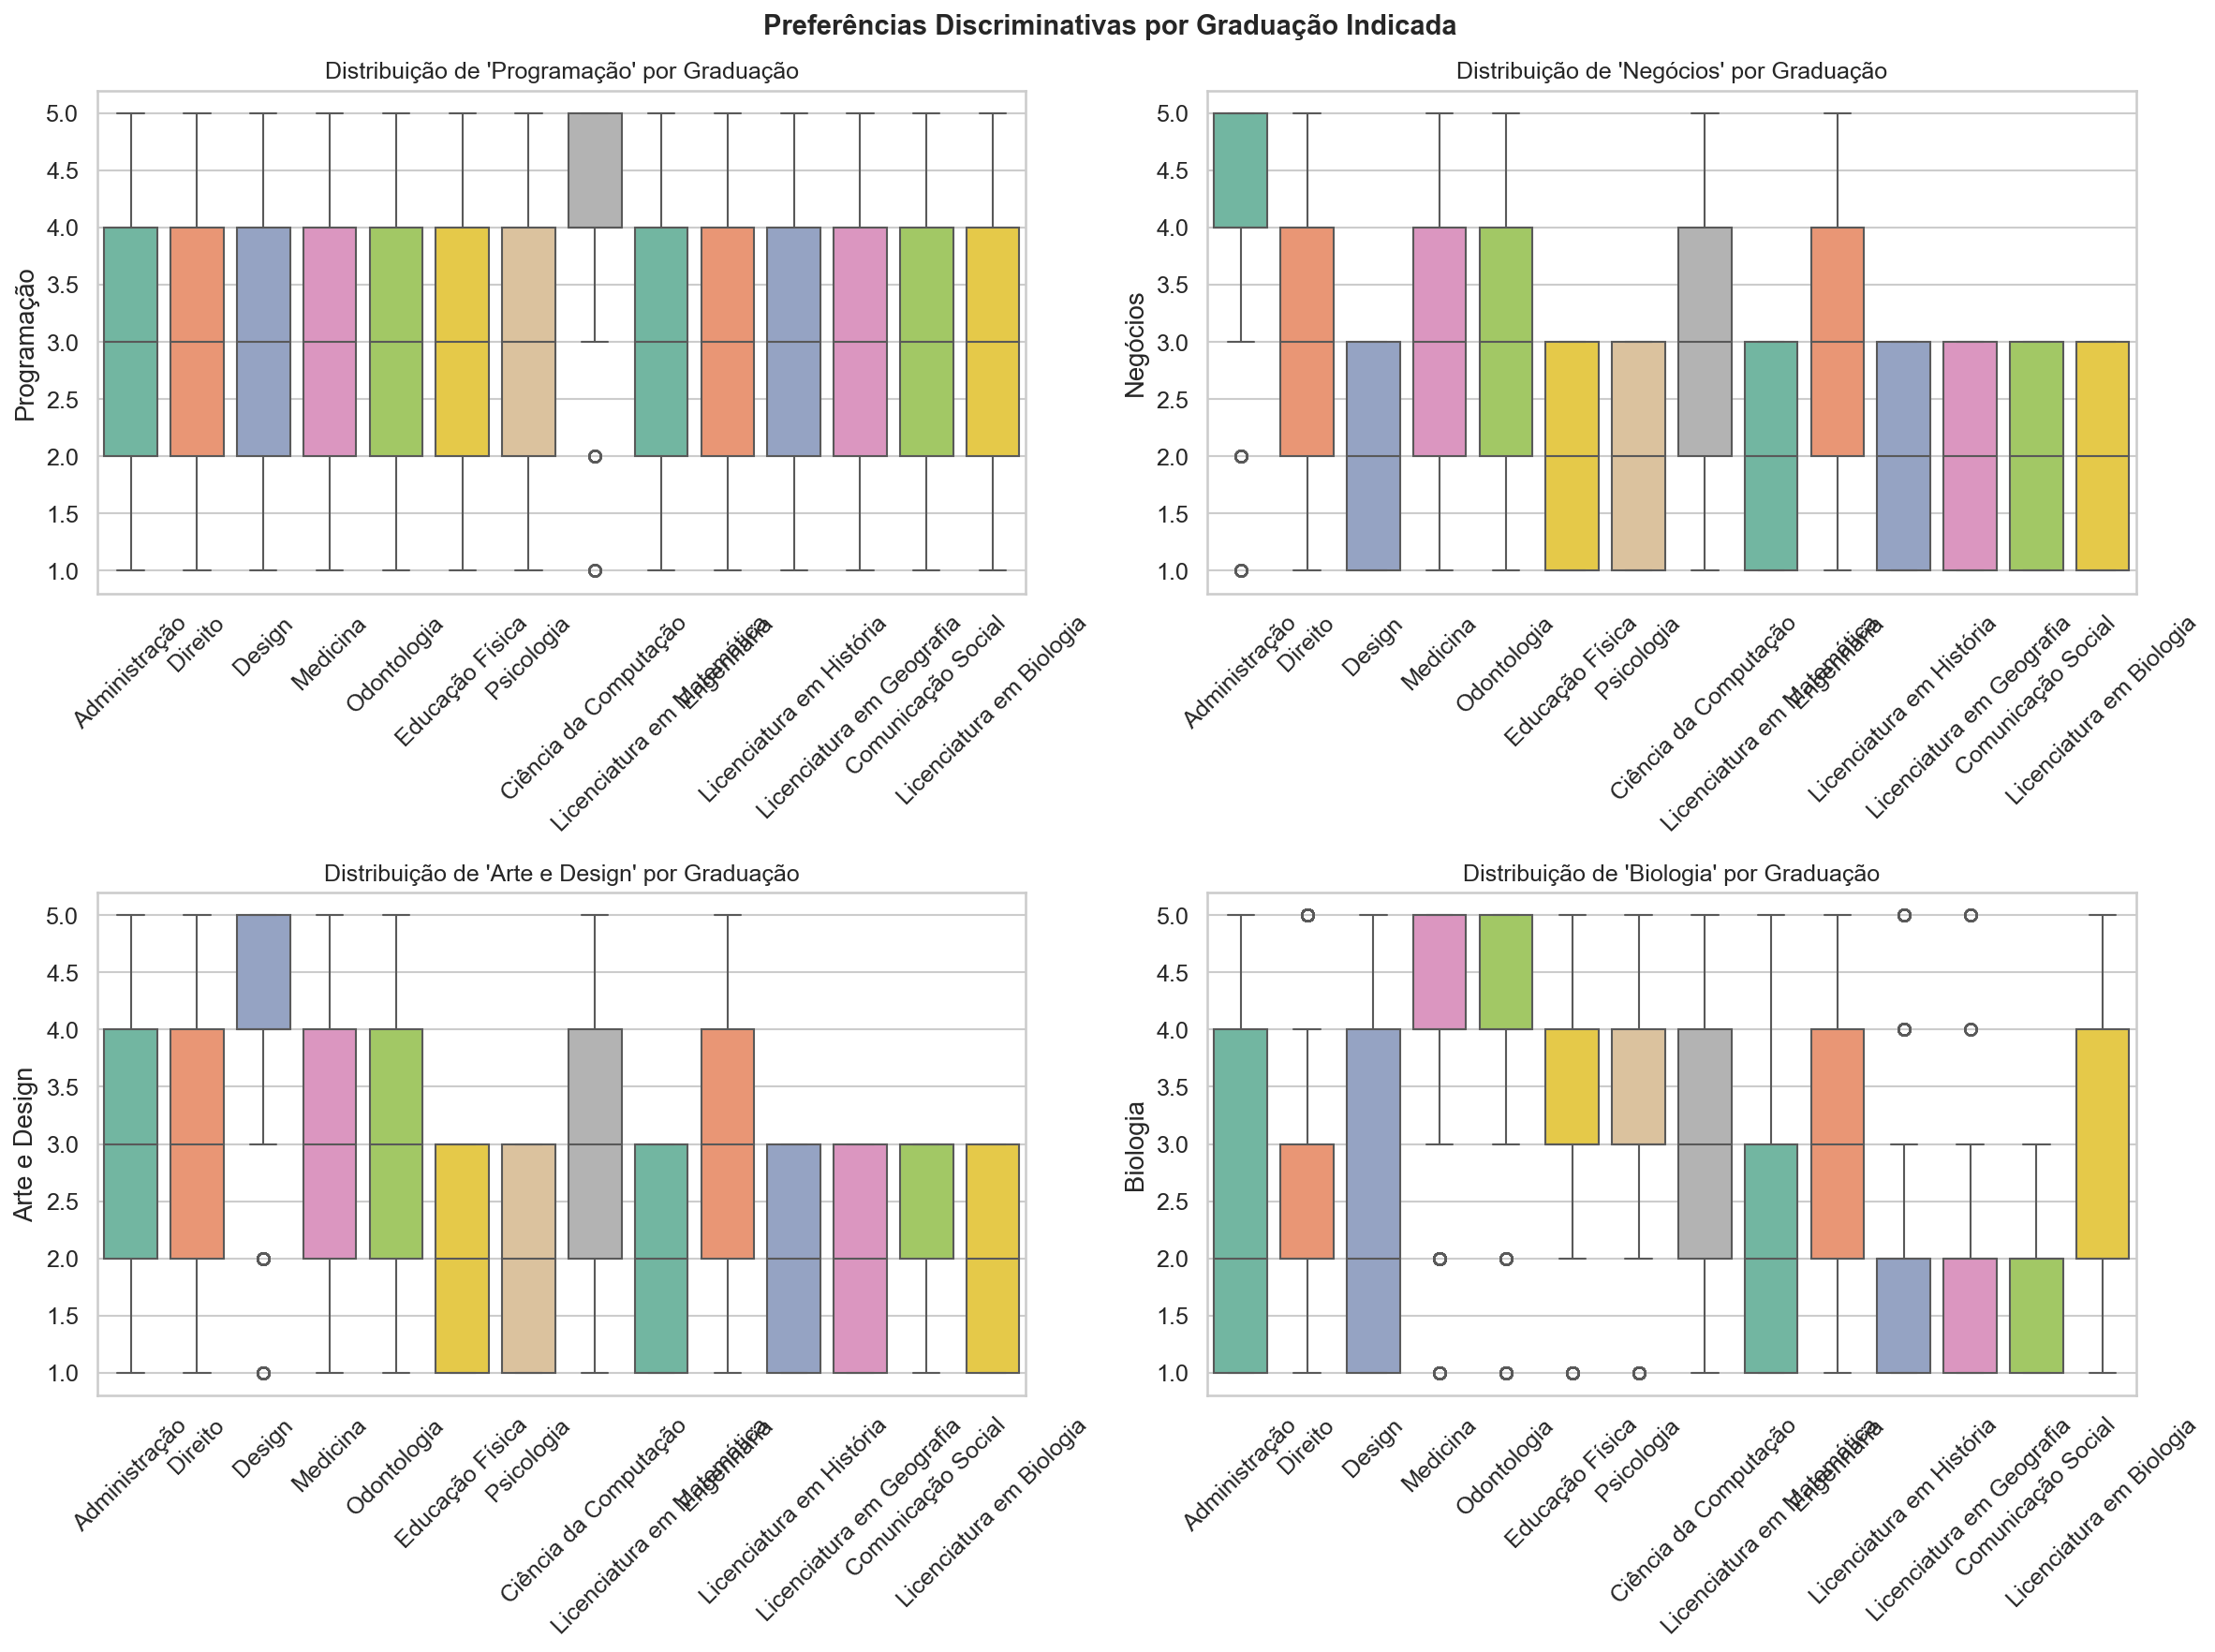

Gráfico salvo em: artefatos/08_boxplot_preferencias_discriminativas.png


In [22]:
# Boxplots das 4 preferências mais discriminativas
prefs_destaque = ["Gosta_Programacao", "Gosta_Negocios", "Gosta_Arte_Design", "Gosta_Biologia"]
nomes_destaque = ["Programação", "Negócios", "Arte e Design", "Biologia"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (coluna, nome) in enumerate(zip(prefs_destaque, nomes_destaque)):
    sns.boxplot(
        data=dados, x="Graduacao_Indicada", y=coluna,
        order=ordem_classes, ax=axes[i], palette="Set2"
    )
    axes[i].set_title(f"Distribuição de '{nome}' por Graduação", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(nome)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Preferências Discriminativas por Graduação Indicada", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/08_boxplot_preferencias_discriminativas.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/08_boxplot_preferencias_discriminativas.png")

### Resultados — Etapa 9

- Os boxplots confirmam os padrões identificados nas médias:
  - **Programação** tem mediana visivelmente mais alta para Ciência da Computação.
  - **Negócios** destaca-se claramente em Administração.
  - **Arte e Design** separa bem a graduação de Design.
  - **Biologia** diferencia Medicina e Odontologia das demais.
- Porém, há **sobreposição considerável** entre classes — os valores de 1 a 5 com distribuição discreta limitam a separação perfeita.
- **Insight**: Modelos baseados em árvore (Decision Tree, Random Forest) podem capturar bem esses limiares discretos. KNN pode ter mais dificuldade com a sobreposição.

---
## Etapa 10 — Análise de Pares de Preferências (Separação entre Classes Similares)

**Objetivo:** Investigar como pares de preferências podem ajudar a separar classes com perfis semelhantes, como Medicina vs Odontologia e Engenharia vs Licenciatura em Matemática.

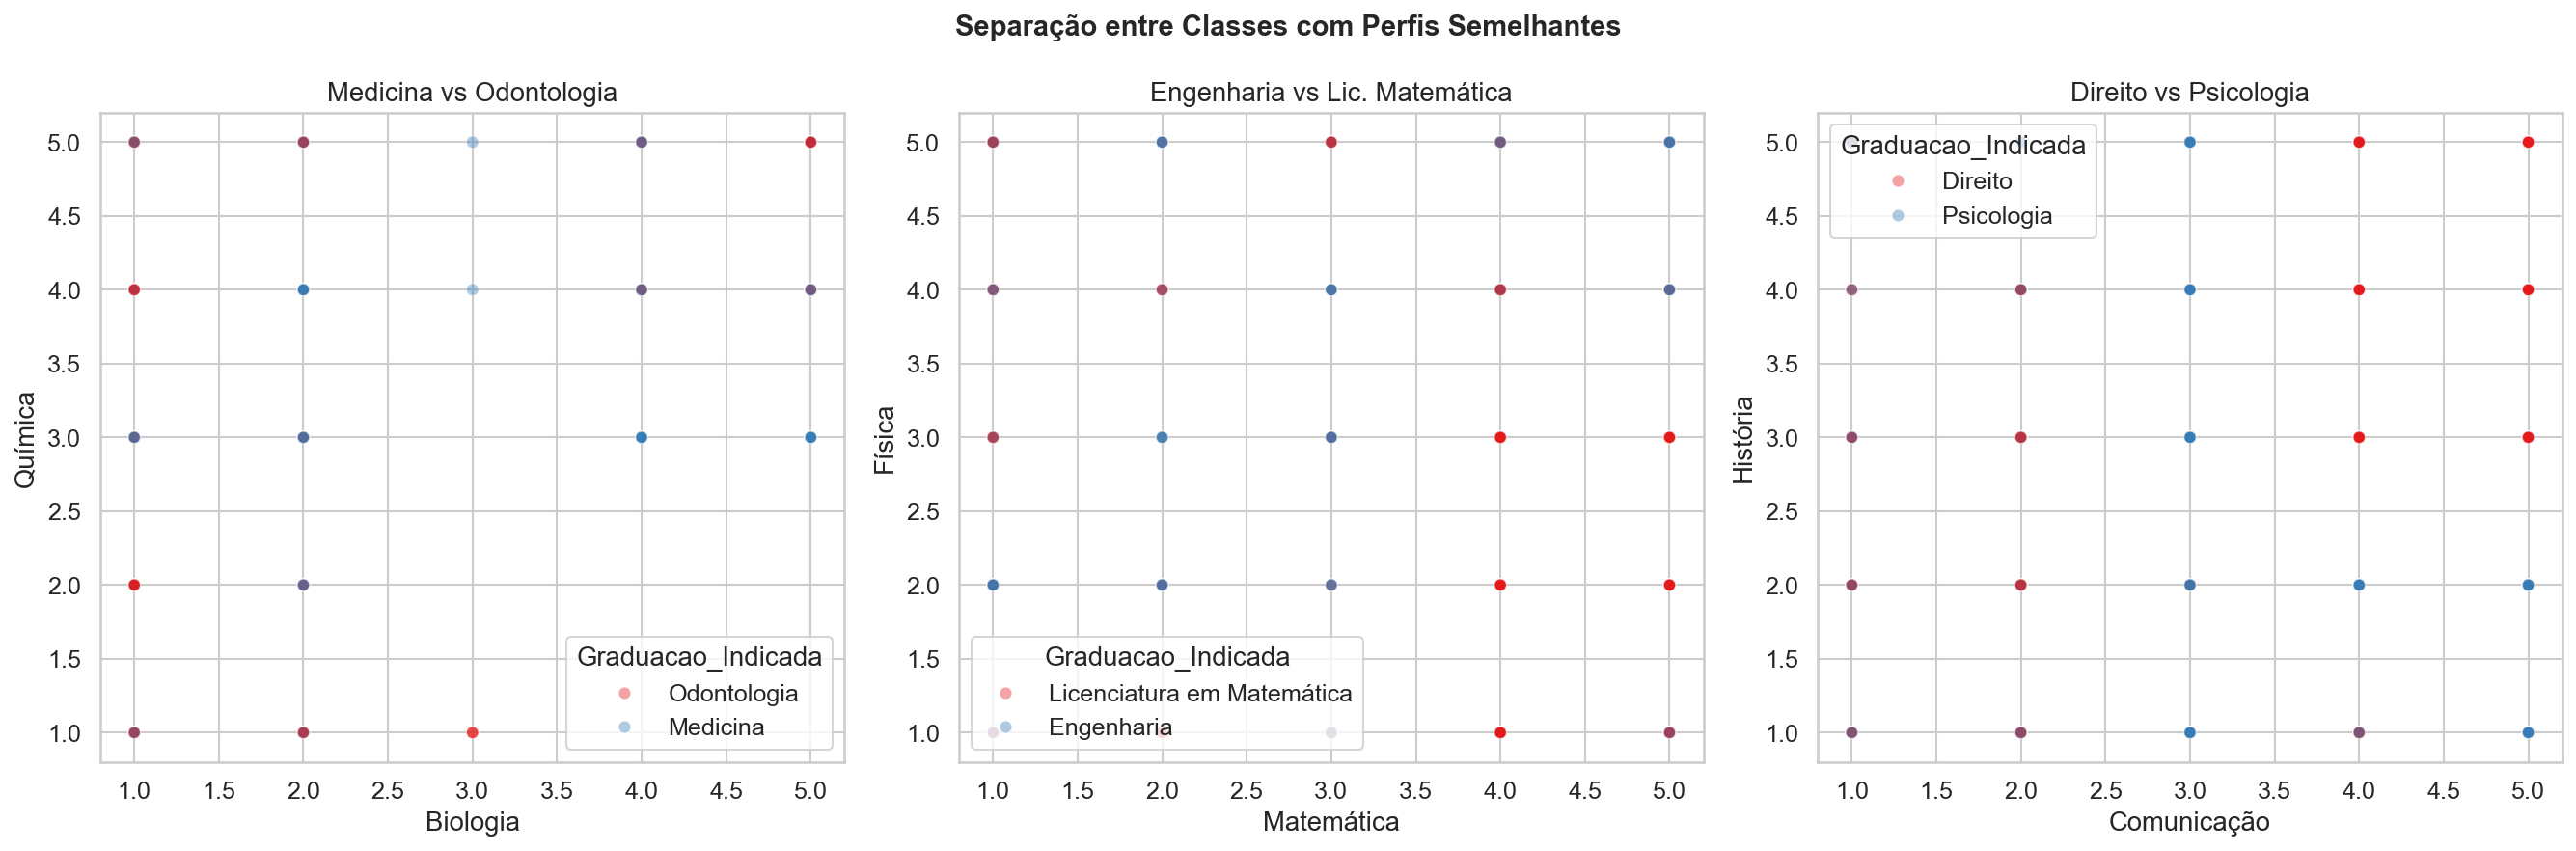

Gráfico salvo em: artefatos/09_scatter_pares_classes_similares.png


In [23]:
# Scatter plots de pares de preferências para classes com perfis semelhantes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Par 1: Medicina vs Odontologia (Biologia x Química)
filtro_1 = dados["Graduacao_Indicada"].isin(["Medicina", "Odontologia"])
sns.scatterplot(
    data=dados[filtro_1], x="Gosta_Biologia", y="Gosta_Quimica",
    hue="Graduacao_Indicada", alpha=0.4, ax=axes[0], palette="Set1"
)
axes[0].set_title("Medicina vs Odontologia")
axes[0].set_xlabel("Biologia")
axes[0].set_ylabel("Química")

# Par 2: Engenharia vs Lic. Matemática (Matemática x Física)
filtro_2 = dados["Graduacao_Indicada"].isin(["Engenharia", "Licenciatura em Matemática"])
sns.scatterplot(
    data=dados[filtro_2], x="Gosta_Matematica", y="Gosta_Fisica",
    hue="Graduacao_Indicada", alpha=0.4, ax=axes[1], palette="Set1"
)
axes[1].set_title("Engenharia vs Lic. Matemática")
axes[1].set_xlabel("Matemática")
axes[1].set_ylabel("Física")

# Par 3: Direito vs Psicologia (Comunicação x História)
filtro_3 = dados["Graduacao_Indicada"].isin(["Direito", "Psicologia"])
sns.scatterplot(
    data=dados[filtro_3], x="Gosta_Comunicacao", y="Gosta_Historia",
    hue="Graduacao_Indicada", alpha=0.4, ax=axes[2], palette="Set1"
)
axes[2].set_title("Direito vs Psicologia")
axes[2].set_xlabel("Comunicação")
axes[2].set_ylabel("História")

plt.suptitle("Separação entre Classes com Perfis Semelhantes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PASTA_ARTEFATOS}/09_scatter_pares_classes_similares.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {PASTA_ARTEFATOS}/09_scatter_pares_classes_similares.png")

### Resultados — Etapa 10

- **Medicina vs Odontologia**: Ambas possuem Biologia e Química altas. A separação é sutil — Odontologia tende a ter Química ligeiramente mais alta (4.44 vs 3.98). Modelos podem confundir essas classes.
- **Engenharia vs Lic. Matemática**: Engenharia combina Matemática + Física alta, enquanto Lic. Matemática tem apenas Matemática alta e Física média. A Física é o diferenciador.
- **Direito vs Psicologia**: Direito tem Comunicação + História altas; Psicologia tem Comunicação + Biologia. A História é o diferenciador.
- **Insight**: A separação entre classes similares depende de **combinações específicas de features**, não de uma única feature. Modelos baseados em árvore capturam bem essas interações.

---
## Conclusão da Análise Exploratória

### Síntese dos principais achados

| Aspecto | Resultado |
|---|---|
| **Qualidade dos dados** | Excelente — zero nulos, zero duplicados, valores consistentes |
| **Desbalanceamento** | Severo (35.5x) — as 4 maiores classes representam 67% dos dados |
| **Features mais discriminativas** | As 10 preferências de interesse (escala 1-5) |
| **Features menos discriminativas** | Idade e Anos_Para_Formar (distribuição uniforme entre classes) |
| **Curso Técnico** | Altamente discriminativo apenas para Ciência da Computação (95%) e Engenharia (93%) |
| **Correlação entre features** | Praticamente nula (<0.02) — todas as features são independentes |
| **Classes mais difíceis de separar** | Medicina/Odontologia, Engenharia/Lic. Matemática |
| **Classes minoritárias em risco** | Lic. Biologia (130), Comunicação Social (209), Lic. Geografia (287) |

### Decisões para a próxima etapa

1. **Métrica principal**: F1-Score Macro — indispensável pelo desbalanceamento severo.
2. **Split estratificado**: Obrigatório (`stratify=y`) para garantir representatividade das classes minoritárias.
3. **Todas as 13 features serão mantidas**: não há redundância, e cada uma contribui com informação útil.
4. **Pré-processamento**: `LabelEncoder` para `Curso_Tecnico` + `StandardScaler` para normalizar (necessário para KNN).
5. **Modelos prioritários**: Random Forest e Decision Tree (capturam interações entre features discretas). KNN como baseline.

---

## Próximos Passos

1. **Etapa 3 — Transformação dos Dados**: Implementar o pipeline de pré-processamento em `src/data_transform.py`.
2. **Etapa 4 — Modelagem**: Treinar Decision Tree, Random Forest e KNN com registro no MLflow (`src/train.py`).
3. **Etapa 5 — Avaliação**: Comparar modelos por F1 Macro e salvar o melhor (`src/evaluate.py`).
4. **Etapa 6 — Deploy**: Criar a interface Streamlit e publicar no Hugging Face Spaces (`app.py`).